## Mini-Project 1: A1C Testing, Race, Age, Medical Specialty, Insurance, and Hospital Readmission

Exploratory analysis of the **Diabetes 130-US Hospitals (1999-2008)** dataset,
built without a predetermined question — the goal this week is to explore
messy real data, notice something worth investigating, and follow it rigorously.

**Full write-up with methodology, findings, and conclusions:**
see `docs/Week2_A1C_Readmission_Analysis.md`

This notebook contains the actual analysis code behind that write-up. Short
context comments are included before each major step, but the write-up
document is the place to look for full interpretation and reasoning.

**Setup:** run `python src/build_project_db.py`-style raw file placement first —
see the README's Setup section for where `diabetic_data.csv` and
`IDS_mapping.csv` should live (`data/raw/`).

**Import Packages and Read the Data**

In [ ]:
import pandas as pd
import numpy as np
import re

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency

from src.data_cleaning import fill_vars, fill_missing_values

In [123]:
diabetic_df = pd.read_csv("data/raw/diabetic_data.csv")
ids_mapping_df = pd.read_csv('data/raw/IDS_mapping.csv', keep_default_na=False, na_values=[''])

In [124]:
# Print the first few records
diabetic_df.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


**Data Cleaning**

In [125]:
# Replace "?" with a nan
diabetic_df = diabetic_df.replace("?", np.nan)

In [126]:
# Unformation about the diabetic dataframe
diabetic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [ ]:
# Distribution of A1C Tests - 84,748 (~83%) patients were not tested
diabetic_df["A1Cresult"].value_counts(dropna=False)

A1Cresult
NaN     84748
>8       8216
Norm     4990
>7       3812
Name: count, dtype: int64

In [127]:
diabetic_df["A1Cresult"].value_counts(dropna=False, normalize='index')

A1Cresult
NaN     0.832773
>8      0.080734
Norm    0.049034
>7      0.037458
Name: proportion, dtype: float64

In [128]:
ids_mapping_df.head(60)

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped
8,NaN,NaN
9,discharge_disposition_id,description


The IDS Mapping dataframe will be split into 3 dataframes (admission type, discharge disposition, and admission source). NULL is not a missing value!

In [129]:
# 1. Identify the row indices where the sub-tables start
# We look for the literal strings in the first column
idx_discharge = ids_mapping_df[ids_mapping_df.iloc[:, 0] == 'discharge_disposition_id'].index[0]
idx_source = ids_mapping_df[ids_mapping_df.iloc[:, 0] == 'admission_source_id'].index[0]

# 2. Slice and clean the Admission Type DataFrame
df_admission = ids_mapping_df.iloc[:idx_discharge].dropna(subset=[ids_mapping_df.columns[0]]).copy()

# 3. Slice, fix headers, and clean the Discharge Disposition DataFrame
df_discharge_raw = ids_mapping_df.iloc[idx_discharge:idx_source]
df_discharge = df_discharge_raw.iloc[1:].copy()  # Remove header row text
df_discharge.columns = ['discharge_disposition_id', 'description']
df_discharge = df_discharge.reset_index(drop=True)  # Set proper column names
df_discharge = df_discharge.dropna(subset=[df_discharge.columns[0]])

# 4. Slice, fix headers, and clean the Admission Source DataFrame
df_source_raw = ids_mapping_df.iloc[idx_source:]
df_source = df_source_raw.iloc[1:].copy()      # Remove header row text
df_source.columns = ['admission_source_id', 'description']
df_source = df_source.reset_index(drop=True)     # Set proper column names
df_source = df_source.dropna(subset=[df_source.columns[0]])

# Now conert the IDs into integers

# 5. Convert Admission Type ID
df_admission['admission_type_id'] = pd.to_numeric(
    df_admission['admission_type_id'], errors='coerce'
).astype('Int64')

# 6. Convert Discharge Disposition ID
df_discharge['discharge_disposition_id'] = pd.to_numeric(
    df_discharge['discharge_disposition_id'], errors='coerce'
).astype('Int64')

# 7. Convert Admission Source ID
df_source['admission_source_id'] = pd.to_numeric(
    df_source['admission_source_id'], errors='coerce'
).astype('Int64')

In [130]:
df_admission

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped


In [65]:
df_discharge.head()

,discharge_disposition_id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...


In [131]:
df_source.head()

,admission_source_id,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)


In [132]:
# Rename the description column in the 3 dataframes
df_admission = df_admission.rename(columns={'description': 'admission_type_desc'})
df_discharge = df_discharge.rename(columns={'description': 'discharge_disposition_desc'})
df_source = df_source.rename(columns={'description': 'admission_source_desc'})

In [ ]:
# Which columns have null values
diabetic_df.isnull().sum()[lambda x: x > 0]

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
max_glu_serum        96420
A1Cresult            84748
dtype: int64

In [70]:
missing_rate_by_admission = (
    diabetic_df.groupby('admission_type_id')['race']
    .apply(lambda x: x.isnull().mean().round(2)*100)
)
missing_rate_by_admission

admission_type_id
1    2.0
2    4.0
3    2.0
4    0.0
5    1.0
6    1.0
7    5.0
8    1.0
Name: race, dtype: float64

**Cleaning decisions (full rationale in the write-up doc):** each column below
is filled based on what its missingness actually means, not a blanket rule.
`max_glu_serum`/`A1Cresult` missing = test not ordered (a real clinical fact,
kept as its own category). `payer_code`/`medical_specialty`/`race` missing =
administrative gaps, recoded as "Unknown" rather than dropped or imputed.

In [ ]:
# Import fill_vars and fill_missing_values from src.data_cleaning
# Missing values in the variables A1Cresult and max_glu_serum are replaced by Not tested
# For payer_code, medical_specialty, and race, they are replaced by Unknown. 
# However, missing values in diag_2 and diag_3 are replaced by None recorder
fill_map = {
        "max_glu_serum": "Not tested",
        "A1Cresult": "Not tested",
        "payer_code": "Unknown",
        "medical_specialty": "Unknown",
        "race": "Unknown",
        "diag_2": "None recorded",
        "diag_3": "None recorded"
        }
# Fill the missing values in the diabetic datafarme
diabetic_df_cleaned = fill_missing_values(diabetic_df, fill_map)

In [134]:
diabetic_df_cleaned.isnull().sum()[lambda x: x > 0]

weight    98569
diag_1       21
dtype: int64

**`weight` is dropped entirely** (96.9% missing — no analyzable signal
remains) and rows missing `diag_1` are dropped (only 21 rows, the primary
diagnosis field). `diag_2`/`diag_3` were already recoded above rather than
dropped, since losing the primary diagnosis field was judged worse than
keeping an incomplete secondary one.

In [135]:
# Create the cleaned dataframe by dropping weight and the missing rows in diag_1
diabetic_df_cleaned = diabetic_df_cleaned.drop(columns=["weight"]).dropna(subset=["diag_1"]).reset_index(drop=True)
diabetic_df_cleaned.isnull().sum()[lambda x: x > 0]

Series([], dtype: int64)

In [136]:
# Test the cleaned diabetic dataframe
print(diabetic_df_cleaned["A1Cresult"].value_counts(dropna=False))

A1Cresult
Not tested    84730
>8             8214
Norm           4989
>7             3812
Name: count, dtype: int64


In [137]:
print(diabetic_df_cleaned["payer_code"].value_counts(dropna=False).head())

payer_code
Unknown    40245
MC         32432
HM          6273
SP          5007
BC          4655
Name: count, dtype: int64


In [138]:
diabetic_df_cleaned.groupby('race', dropna=False)['readmitted'].count()

race
AfricanAmerican    19201
Asian                640
Caucasian          76092
Hispanic            2035
Other               1506
Unknown             2271
Name: readmitted, dtype: int64

In [139]:
# Convert data type of IDs from Int to int before merging
df_admission['admission_type_id'] = df_admission['admission_type_id'].astype('int64')
df_discharge['discharge_disposition_id'] = df_discharge['discharge_disposition_id'].astype('int64')
df_source['admission_source_id'] = df_source['admission_source_id'].astype('int64')

In [140]:
df_admission

,admission_type_id,admission_type_desc
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NULL
6,7,Trauma Center
7,8,Not Mapped


In [141]:
# Merge the the 3 ID dataframes with the diabetic dataset
diabetic_df_cleaned = diabetic_df_cleaned.merge(df_admission, on='admission_type_id', how='left')
diabetic_df_cleaned = diabetic_df_cleaned.merge(df_discharge, on='discharge_disposition_id', how='left')
diabetic_df_cleaned = diabetic_df_cleaned.merge(df_source, on='admission_source_id', how='left')

In [142]:
diabetic_df_cleaned.shape

(101745, 52)

In [143]:
print(diabetic_df_cleaned.info())

<class 'pandas.DataFrame'>
RangeIndex: 101745 entries, 0 to 101744
Data columns (total 52 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   encounter_id                101745 non-null  int64
 1   patient_nbr                 101745 non-null  int64
 2   race                        101745 non-null  str  
 3   gender                      101745 non-null  str  
 4   age                         101745 non-null  str  
 5   admission_type_id           101745 non-null  int64
 6   discharge_disposition_id    101745 non-null  int64
 7   admission_source_id         101745 non-null  int64
 8   time_in_hospital            101745 non-null  int64
 9   payer_code                  101745 non-null  str  
 10  medical_specialty           101745 non-null  str  
 11  num_lab_procedures          101745 non-null  int64
 12  num_procedures              101745 non-null  int64
 13  num_medications             101745 non-null  int64
 14 

**Discharged Disposition - Distribution**

In [82]:
diabetic_df_cleaned['discharge_disposition_desc'].value_counts(normalize = True) * 100

discharge_disposition_desc
Discharged to home                                                                                           59.195046
Discharged/transferred to SNF                                                                                13.710747
Discharged/transferred to home with home health service                                                      12.676790
NULL                                                                                                          3.626714
Discharged/transferred to another short term hospital                                                         2.090520
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1.958819
Expired                                                                                                       1.613839
Discharged/transferred to another type of inpatient care institution                                          1.161728
Not Mapped           

In [144]:
# Since patients who died or transferred to hospice can't be readmitted, exclude these records

# The pattern looks for 'expired' OR 'hospice'
# flags=re.IGNORECASE ensures it catches 'Expired', 'HOSPICE', etc.
pattern = "expired|hospice"

# Filter the dataframe to EXCLUDE rows matching the pattern, The ~ symbol means "NOT"
diabetic_df_filtered = diabetic_df_cleaned[
    ~diabetic_df_cleaned["discharge_disposition_desc"].str.contains(
        pattern, flags=re.IGNORECASE, na=False, regex=True
    )
]

In [145]:
list(diabetic_df_filtered['discharge_disposition_desc'].unique())

['Not Mapped',
 'Discharged to home',
 'Discharged/transferred to SNF',
 'Discharged/transferred to home with home health service',
 'Discharged/transferred to another short term hospital',
 'Discharged/transferred to another type of inpatient care institution',
 'Left AMA',
 'Neonate discharged to another hospital for neonatal aftercare',
 'Discharged/transferred to ICF',
 'NULL',
 'Discharged/transferred to home under care of Home IV provider',
 'Still patient or expected to return for outpatient services',
 'Discharged/transferred/referred another institution for outpatient services',
 'Discharged/transferred/referred to this institution for outpatient services',
 'Discharged/transferred to another rehab fac including rehab units of a hospital .',
 'Discharged/transferred to a long term care hospital.',
 'Admitted as an inpatient to this hospital',
 'Discharged/transferred within this institution to Medicare approved swing bed',
 'Discharged/transferred to a nursing facility certifi

**Distribution of A1C Result**

In [146]:
diabetic_df_filtered['A1Cresult'].value_counts(normalize='index').round(3) * 100

A1Cresult
Not tested    83.1
>8             8.2
Norm           5.0
>7             3.8
Name: proportion, dtype: float64

**A1C Result vs. Time in Hospital**

In [147]:
diabetic_df_filtered.groupby('A1Cresult')['time_in_hospital'].mean()

A1Cresult
>7            4.882649
>8            4.739521
Norm          4.918106
Not tested    4.288792
Name: time_in_hospital, dtype: float64

**A1C Result vs. Readmission**

In [ ]:
contingency_table = pd.crosstab(diabetic_df_filtered["A1Cresult"], 
                                diabetic_df_filtered["readmitted"])

# Run the Chi-Square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Print the results nicely
print("=== CHI-SQUARE TEST RESULTS ===")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"p-value:             {p:.4f}")
print(f"Degrees of Freedom:  {dof}")
print("-" * 31)
if p <= 0.05:
    print(
        f"Conclusion: SIGNIFICANT RELATIONSHIP (p <= 0.05).\nA1CResult and readmission are dependent on each other."
    )
else:
    print(
        f"Conclusion: NO SIGNIFICANT RELATIONSHIP (p > 0.05).\nA1Cresult and readmission appear to be independent."
    )

=== CHI-SQUARE TEST RESULTS ===
Chi-Square Statistic: 92.1950
p-value:             0.0000
Degrees of Freedom:  6
-------------------------------
Conclusion: SIGNIFICANT RELATIONSHIP (p <= 0.05).
A1CResult and readmission are dependent on each other.


In [150]:
# Show row percentages (multiplied by 100 for readability)
pd.crosstab(diabetic_df_filtered['A1Cresult'], diabetic_df_filtered['readmitted'], normalize='index').round(2) * 100

readmitted,<30,>30,NO
A1Cresult,,,
>7,10.0,34.0,55.0
>8,10.0,36.0,54.0
Norm,10.0,32.0,58.0
Not tested,12.0,36.0,52.0


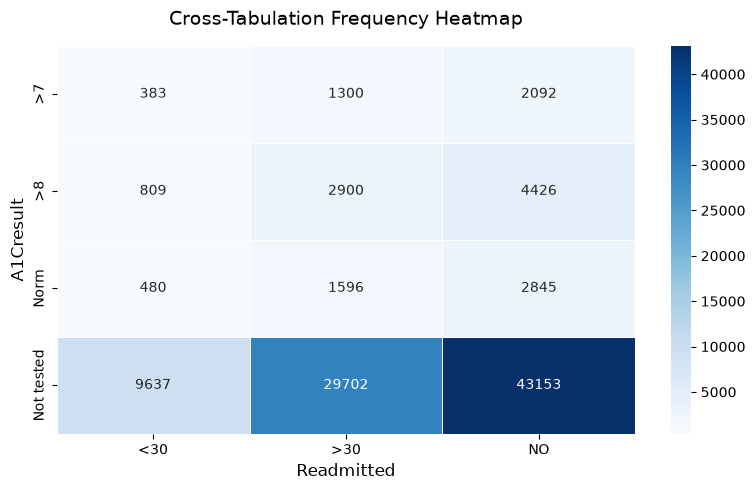

In [151]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    contingency_table,
    annot=True,  # Shows the actual counts inside the boxes
    fmt="d",  # Formats numbers as integers (no decimals)
    cmap="Blues",  # Color gradient palette
    linewidths=0.5,  # Adds a clean border between cells
)

plt.title("Cross-Tabulation Frequency Heatmap", fontsize=14, pad=15)
plt.ylabel("A1Cresult", fontsize=12)
plt.xlabel("Readmitted", fontsize=12)
plt.tight_layout()
plt.show()

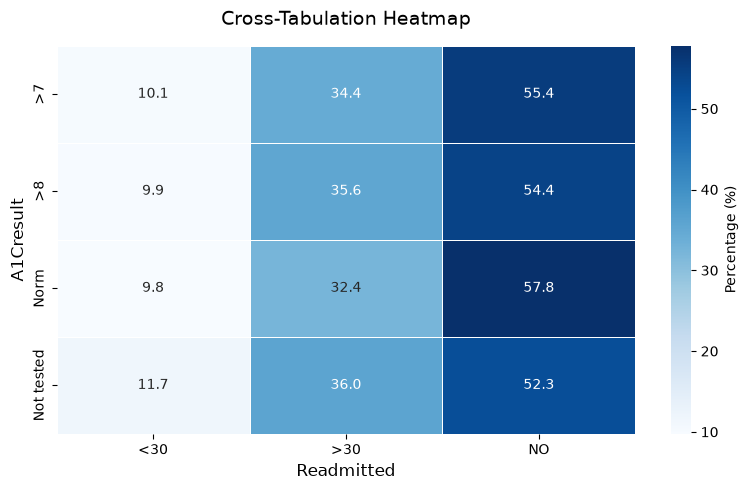

In [152]:
# 1. Generate cross-tabulation with ROW percentages (multiplied by 100)
# 'normalize="index"' scales each row's values to sum to 1.0 (100%)
ct_percent = (
    pd.crosstab(
        diabetic_df_filtered["A1Cresult"],
        diabetic_df_filtered["readmitted"],
        normalize="index",
    )
    * 100
)

# 2. Create the Percentage Heatmap Visual
plt.figure(figsize=(8, 5))
sns.heatmap(
    ct_percent,
    annot=True,  # Shows the percentage numbers inside the boxes
    fmt=".1f",  # Formats numbers to 1 decimal place (e.g., 45.3%)
    cmap="Blues",  # Color gradient palette
    linewidths=0.5,  # Adds a clean border between cells
    cbar_kws={"label": "Percentage (%)"},  # Adds a label to the color scale bar
)

# Add clear labeling showing the percentage context
plt.title(
    "Cross-Tabulation Heatmap",
    fontsize=14,
    pad=15,
)
plt.ylabel("A1Cresult", fontsize=12)
plt.xlabel("Readmitted", fontsize=12)
plt.tight_layout()
plt.show()


**A1C Testing vs. Admission Type**

In [156]:
pd.crosstab(diabetic_df_filtered['A1Cresult'], diabetic_df_filtered['admission_type_desc'], normalize='index') * 100

admission_type_desc,Elective,Emergency,NULL,Newborn,Not Available,Not Mapped,Trauma Center,Urgent
A1Cresult,,,,,,,,
>7,12.741722,57.165563,4.874172,0.052980,3.337748,0.450331,0.000000,21.377483
>8,10.534726,61.192379,7.781192,0.000000,2.704364,0.356484,0.000000,17.430854
Norm,11.786222,63.157895,3.759398,0.000000,1.889860,0.264174,0.081284,19.061166
Not tested,20.296514,51.054648,5.096252,0.009698,5.064734,0.316394,0.016971,18.144790


**Admission Type and Length of Stay**

In [154]:
diabetic_df_filtered.groupby('admission_type_desc')["time_in_hospital"].mean()

admission_type_desc
Elective         4.304807
Emergency        4.361841
NULL             4.569151
Newborn          3.200000
Not Available    3.909898
Not Mapped       3.062500
Trauma Center    5.444444
Urgent           4.595113
Name: time_in_hospital, dtype: float64

**Medical Specialty**

In [153]:
(diabetic_df_filtered['medical_specialty'].value_counts(normalize='index') * 100).round().head(10)

medical_specialty
Unknown                       49.0
InternalMedicine              14.0
Emergency/Trauma               7.0
Family/GeneralPractice         7.0
Cardiology                     5.0
Surgery-General                3.0
Nephrology                     2.0
Orthopedics                    1.0
Orthopedics-Reconstructive     1.0
Radiologist                    1.0
Name: proportion, dtype: float64

In [96]:
top_specialties = diabetic_df_filtered['medical_specialty'].value_counts().head(10).index
subset = diabetic_df_filtered[diabetic_df_filtered['medical_specialty'].isin(top_specialties)]

(pd.crosstab(subset['medical_specialty'], subset['A1Cresult'], normalize='index') * 100).round(2).sort_values(by="Not tested", ascending = False)

A1Cresult,>7,>8,Norm,Not tested
medical_specialty,,,,
Radiologist,1.87,2.23,2.14,93.76
Orthopedics,1.87,2.23,2.66,93.25
Orthopedics-Reconstructive,1.95,3.50,2.68,91.87
Surgery-General,2.91,5.79,3.43,87.87
Nephrology,3.38,6.76,3.45,86.41
Cardiology,3.09,8.07,3.56,85.28
Unknown,3.61,7.09,5.58,83.72
Family/GeneralPractice,3.63,9.42,4.38,82.57
InternalMedicine,4.66,11.43,5.06,78.85


In [99]:
ortho_subset = diabetic_df_filtered[diabetic_df_filtered['medical_specialty'].isin(['Orthopedics', 'Orthopedics-Reconstructive'])]
(pd.crosstab(ortho_subset['A1Cresult'], ortho_subset['readmitted'], normalize='index') * 100).round()

readmitted,<30,>30,NO
A1Cresult,,,
>7,8.0,20.0,72.0
>8,7.0,31.0,62.0
Norm,9.0,26.0,66.0
Not tested,9.0,23.0,67.0


In [100]:
ortho_subset['A1Cresult'].value_counts()

A1Cresult
Not tested    2428
>8              74
Norm            70
>7              50
Name: count, dtype: int64

In [101]:
ortho_contingency = pd.crosstab(ortho_subset['A1Cresult'], ortho_subset['readmitted'])
chi2, p_value, dof, expected = chi2_contingency(ortho_contingency)
print(f"Chi-square: {chi2:.2f}, p-value: {p_value:.4f}")
print(ortho_contingency)  # also check the raw counts, not just percentages

Chi-square: 3.32, p-value: 0.7678
readmitted  <30  >30    NO
A1Cresult                 
>7            4   10    36
>8            5   23    46
Norm          6   18    46
Not tested  228  569  1631


**Race vs. Readmitted**

In [109]:
diabetic_df_filtered['race'].value_counts()

race
Caucasian          74213
AfricanAmerican    18763
Unknown             2232
Hispanic            2015
Other               1472
Asian                628
Name: count, dtype: int64

In [107]:
(pd.crosstab(diabetic_df_filtered['race'], diabetic_df_filtered['readmitted'], normalize='index')*100).round()

readmitted,<30,>30,NO
race,,,
AfricanAmerican,11.0,35.0,53.0
Asian,10.0,26.0,64.0
Caucasian,12.0,37.0,52.0
Hispanic,10.0,32.0,58.0
Other,10.0,30.0,60.0
Unknown,8.0,24.0,68.0


In [110]:
contingency_race = pd.crosstab(diabetic_df_filtered['race'], diabetic_df_filtered['readmitted'])
chi2, p_value, dof, expected = chi2_contingency(contingency_race)
print(f"Chi-square: {chi2:.2f}, p-value: {p_value}")

Chi-square: 302.26, p-value: 5.165729743875119e-59


In [108]:
diabetic_df_filtered.groupby('race')['time_in_hospital'].mean()

race
AfricanAmerican    4.490487
Asian              3.958599
Caucasian          4.368803
Hispanic           4.050620
Other              4.257473
Unknown            4.296147
Name: time_in_hospital, dtype: float64

**Insurance vs. Race**

In [112]:
top_payers = diabetic_df_filtered['payer_code'].value_counts().head(6).index
subset = diabetic_df_filtered[diabetic_df_filtered['payer_code'].isin(top_payers)]
(pd.crosstab(subset['race'], subset['payer_code'], normalize='index') * 100).round()

payer_code,BC,HM,MC,MD,SP,Unknown
race,,,,,,
AfricanAmerican,5.0,5.0,27.0,6.0,3.0,54.0
Asian,5.0,4.0,22.0,9.0,12.0,49.0
Caucasian,5.0,7.0,37.0,3.0,6.0,41.0
Hispanic,5.0,5.0,18.0,10.0,7.0,56.0
Other,4.0,6.0,21.0,9.0,9.0,52.0
Unknown,6.0,8.0,42.0,5.0,12.0,27.0


**Race vs. Age**

In [113]:
(pd.crosstab(diabetic_df_filtered['race'], diabetic_df_filtered['age'], normalize='index')*100).round()

age,[0-10),[10-20),[20-30),[30-40),[40-50),[50-60),[60-70),[70-80),[80-90),[90-100)
race,,,,,,,,,,
AfricanAmerican,0.0,1.0,3.0,7.0,15.0,22.0,22.0,20.0,9.0,2.0
Asian,0.0,0.0,1.0,2.0,8.0,19.0,25.0,28.0,14.0,2.0
Caucasian,0.0,1.0,1.0,3.0,8.0,16.0,22.0,27.0,19.0,3.0
Hispanic,0.0,1.0,3.0,9.0,17.0,20.0,24.0,19.0,7.0,1.0
Other,0.0,1.0,2.0,6.0,11.0,21.0,28.0,21.0,10.0,1.0
Unknown,0.0,0.0,2.0,3.0,10.0,16.0,22.0,26.0,17.0,3.0


In [115]:
diabetic_df_filtered["max_glu_serum"].value_counts()

max_glu_serum
Not tested    94172
Norm           2544
>200           1419
>300           1188
Name: count, dtype: int64

**Maximum Glucose Serum**

In [118]:
(pd.crosstab(diabetic_df_filtered['max_glu_serum'], diabetic_df_filtered['readmitted'], normalize='index') * 100).round()

readmitted,<30,>30,NO
max_glu_serum,,,
>200,13.0,37.0,50.0
>300,15.0,44.0,41.0
Norm,12.0,35.0,54.0
Not tested,11.0,36.0,53.0


In [119]:
contingency_glucose = pd.crosstab(diabetic_df_filtered['max_glu_serum'], diabetic_df_filtered['readmitted'])
chi2, p_value, dof, expected = chi2_contingency(contingency_glucose)
print(f"Chi-square: {chi2:.2f}, p-value: {p_value}")

Chi-square: 76.46, p-value: 1.9199411874241317e-14
